In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy.stats as stats      #  this library is used for Q.Q ploting
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv('Titanic.csv',usecols=['Age','Survived','Fare',])

In [5]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
#want to ramove  the null 
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\HEC\AppData\Local\Temp\ipykernel_14552\3228120722.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [8]:
df

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [9]:
# know separate input and output frm data
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [10]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [11]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [12]:
x_train.drop_duplicates()

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


In [13]:
y_test.shape

(179,)

In [14]:
y_train.shape

(712,)

In [15]:
x_test.shape

(179, 2)

In [16]:
x_train.shape

(712, 2)

In [17]:
x_test.drop_duplicates()

,Age,Fare
709,29.699118,15.2458
439,31.000000,10.5000
840,20.000000,7.9250
720,6.000000,33.0000
39,14.000000,11.2417
...,...,...
433,17.000000,7.1250
773,29.699118,7.2250
25,38.000000,31.3875
84,17.000000,10.5000


In [18]:
y_test.drop_duplicates()

709    1
439    0
Name: Survived, dtype: int64

In [19]:
y_train.drop_duplicates()

331    0
55     1
Name: Survived, dtype: int64

Text(0.5, 1.0, 'Age PDF ')

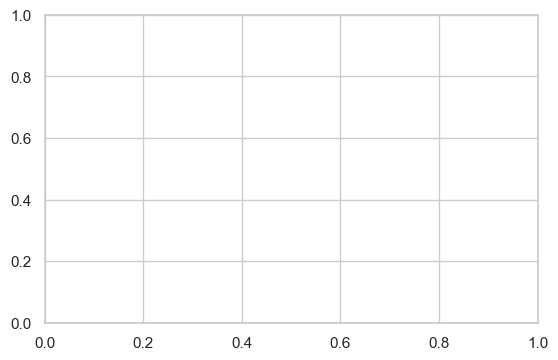

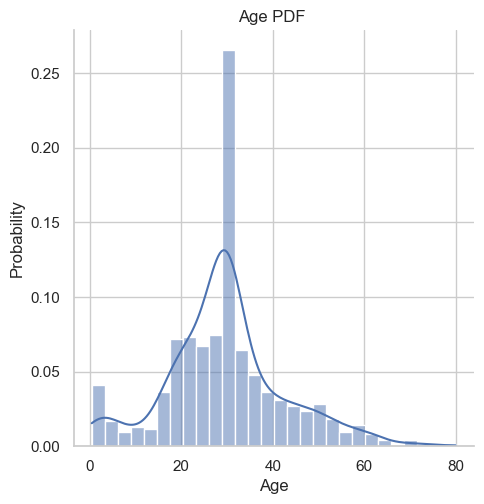

In [20]:
# now we see that the the values of data is distribute normly or not 
plt.figure(figsize=(14,4))
sns.set_theme(style="whitegrid")
plt.subplot(122)
sns.displot(x_train['Age'],kde=True,stat="probability")
plt.title('Age PDF ')



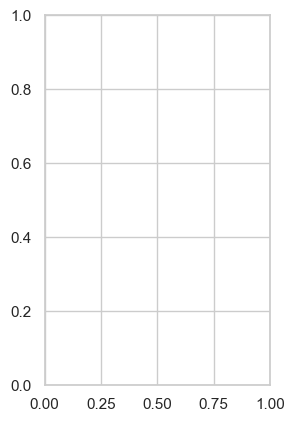

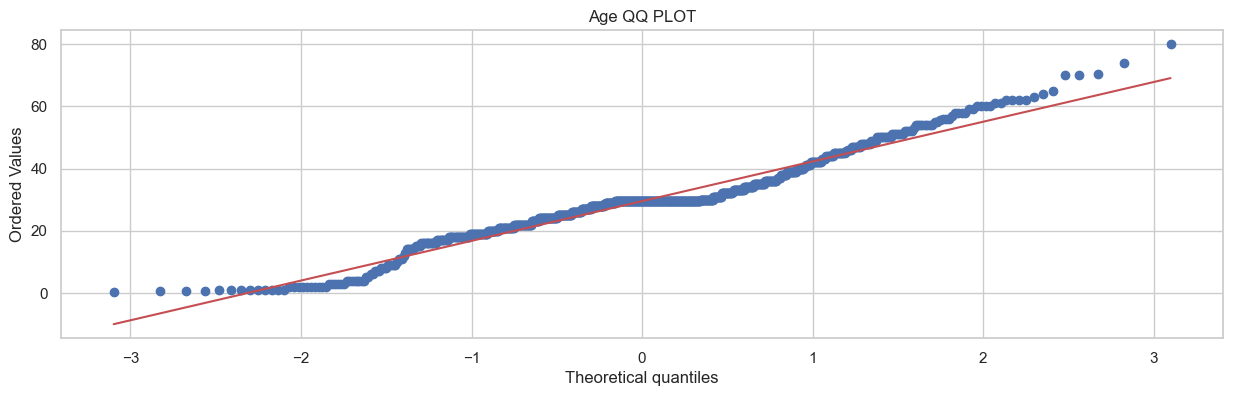

In [21]:
plt.subplot(122)
plt.figure(figsize=(15,4))           # this this another mathod to identify i data is normaly destributed or not

stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ PLOT')
plt.show()

In [22]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [23]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)
y_pred=clf.predict(x_test)
y_pred=clf2.predict(x_test)

print("accuracy of Lr",accuracy_score(y_test,y_pred))
print("accuracy of Dt",accuracy_score(y_test,y_pred))

accuracy of Lr 0.664804469273743
accuracy of Dt 0.664804469273743


Text(0.5, 1.0, 'fare PDF ')

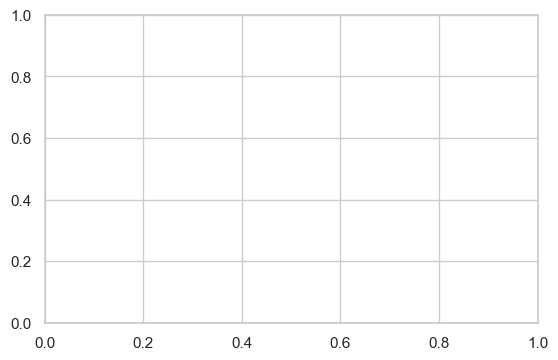

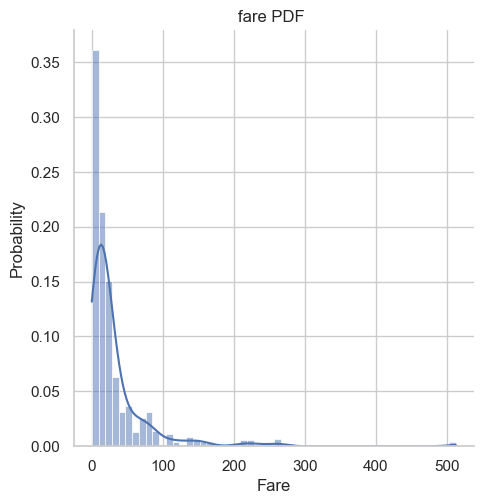

In [24]:
plt.figure(figsize=(14,4))
plt.subplot(122)
sns.displot(x_train['Fare'],kde=True,stat="probability")
plt.title('fare PDF ')

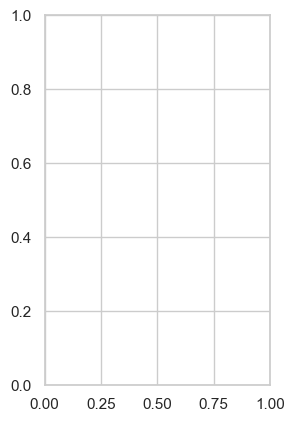

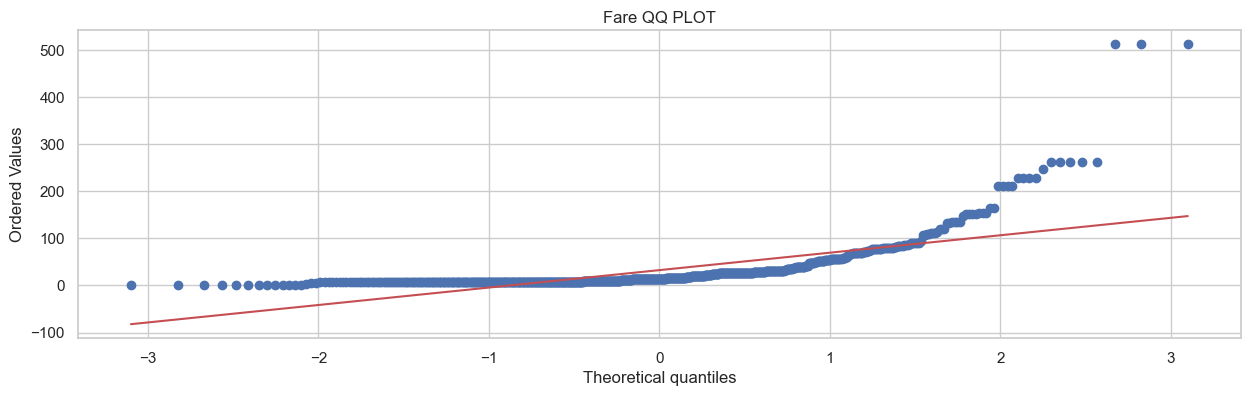

In [25]:
plt.subplot(122)
plt.figure(figsize=(15,4))           # this this another mathod to identify i data is normaly destributed or not

stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ PLOT')
plt.show()

In [26]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [27]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)
y_pred=clf.predict(x_test)
y_pred=clf2.predict(x_test)

print("accuracy of Lr",accuracy_score(y_test,y_pred))
print("accuracy of Dt",accuracy_score(y_test,y_pred))

accuracy of Lr 0.664804469273743
accuracy of Dt 0.664804469273743


In [28]:
#lOG TRANSFOR WE APPLY because we know if data destribution is in left side te will ued LOG transfor

LOG TRANSFOR

In [29]:
trf=FunctionTransformer(func=np.log1p)

In [30]:
x_train_transfor=trf.fit_transform(x_train)
x_test_transfor=trf.fit_transform(x_test)

In [31]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [32]:
clf.fit(x_train_transfor,y_train)
clf2.fit(x_train_transfor,y_train)

y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)

print("Acurracy LR",accuracy_score(y_test,y_pred))
print("Acurracy DT",accuracy_score(y_test,y_pred2))

Acurracy LR 0.7374301675977654
Acurracy DT 0.5865921787709497


In [33]:
# so if we see due to log transform the impct cme on LR LR improve his performance so we learn that there are certain algoritham which effect but some dont effect

In [34]:
x_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("Acuuracy of LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("Accuracy  of DT",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

Acuuracy of LR 0.678027465667915
Accuracy  of DT 0.6588639200998753


In [35]:
#so after 10 mean of values and LR is greater so LR is best

In [36]:
# now we is the transformation work so we ry before and after

Text(0.5, 1.0, 'fare before Log')

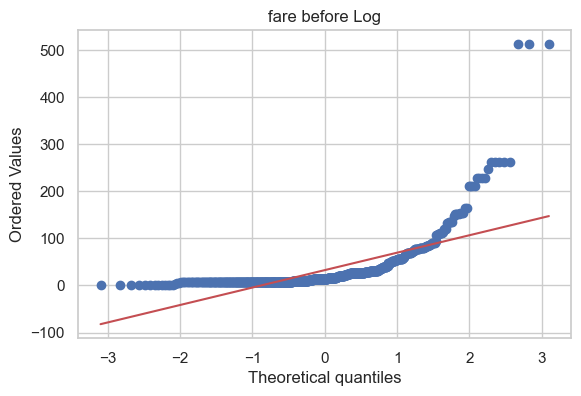

In [37]:
plt.figure(figsize=(14,4))

plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('fare before Log')




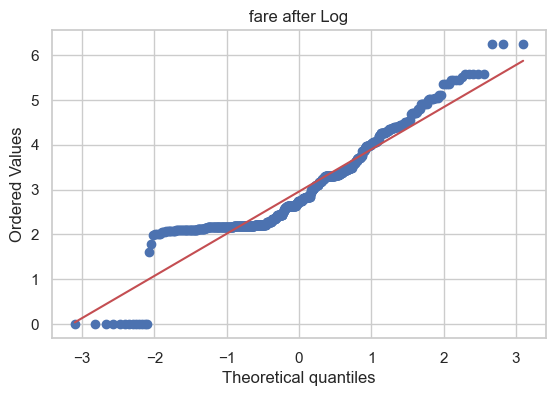

In [38]:
plt.figure(figsize=(14,4))
plt.subplot(122)
stats.probplot(x_train_transfor['Fare'],dist='norm',plot=plt)
plt.title('fare after Log')
plt.show()

In [39]:
# so is whole process we see that the value of dession tree dont change because this does not depend how data is distribute
#LR and linear R is depend on data destribution

In [40]:
# if we apply same thing on age the data will dis distribute ore because log is not best for age  best for fare becue fare is present left side

In [80]:
def apply_transform(transform):
    x=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf=ColumnTransformer([
        ('log',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough')
    x_trans=trf.fit_transform(x)
    clf=LogisticRegression()
    print("Accuracy of LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
    plt.Figure(figsize=(16,8))
    plt.subplot(121)
    stats.probplot(x['Fare'],dist='norm',plot=plt)
    plt.title('fare before transform',fontsize=16)

    plt.subplot(122)
    stats.probplot(x_trans[:,0],dist='norm',plot=plt)
    plt.title('fare after transform',fontsize=16)
    plt.tight_layout()
    plt.show()
    
    
    
    

Accuracy of LR 0.678027465667915


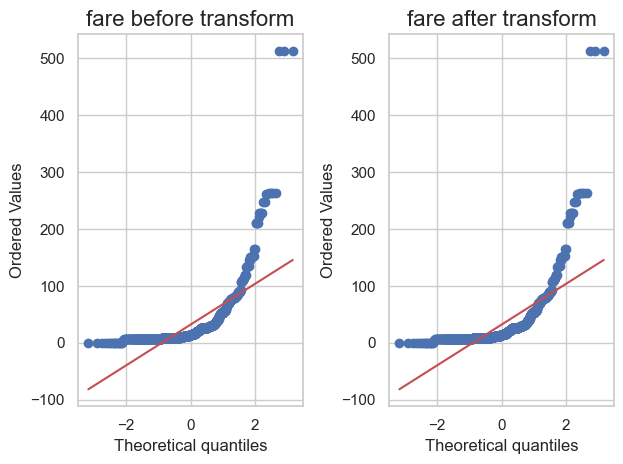

In [81]:
apply_transform(lambda x : x)

Accuracy of LR 0.678027465667915


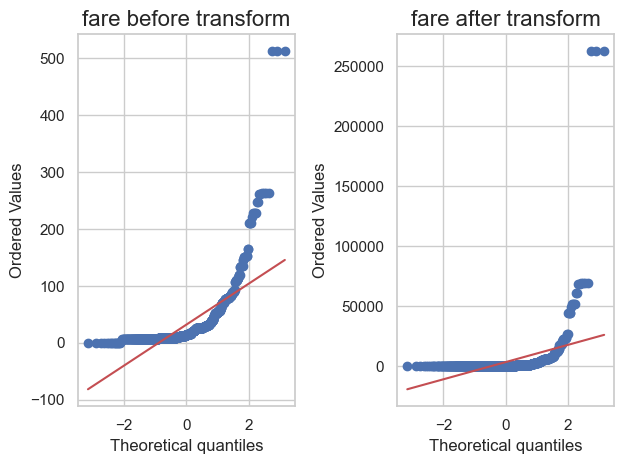

In [82]:
apply_transform(lambda x: x**2)    # sqare transform   # not much happend


Accuracy of LR 0.678027465667915


C:\Users\HEC\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\HEC\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


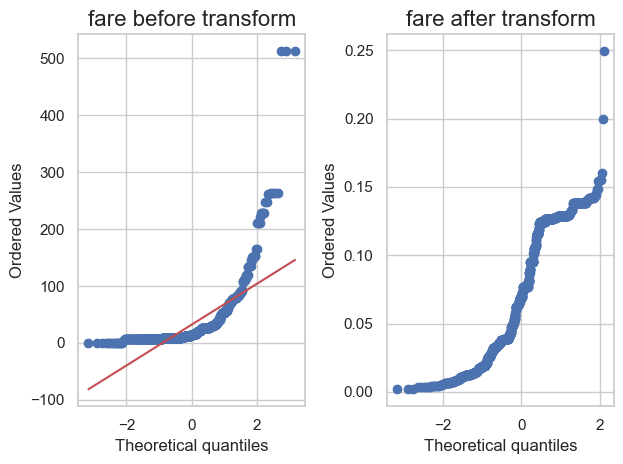

In [84]:
apply_transform(lambda x :1/x)    #reciprocol tranformation
